In [1]:
import pandas

In [2]:
import matplotlib, matplotlib.pyplot
matplotlib.rcParams.update({'font.size':20, 
                            'font.family':'sans-serif', 
                            'xtick.labelsize':16, 
                            'ytick.labelsize':16, 
                            'figure.figsize':(16*(2/3), 9*(2/3)), 
                            'axes.labelsize':20
                           })

In [3]:
input_file = '/Users/adrian/research/bmcbf/004_keilir/results/post_idr_peaks/tmp.a.step3.bed'

In [4]:
df = pandas.read_csv(input_file, sep='\t', header=None)
df

,0,1,2,3,4,5,6,7,8
0,chr1,910547,911772,4.52806,5.17721,13.06390,39.6423,12.06710,35.74030
1,chr1,912004,912799,4.65271,4.8696,6.00938,11.1678,5.06877,9.74975
2,chr1,921531,924309,4.57308,5.51969,10.27530,23.7702,8.26056,23.88580
3,chr1,930276,932047,4.24925,4.30124,9.65252,21.6962,8.75218,22.58680
4,chr1,936850,940044,4.33985,5.61777,12.14350,36.5068,8.61369,32.58250
...,...,...,...,...,...,...,...,...,...
41659,chrUn_GL000216v2,141290,142105,7.07509,12.2004,13.07760,34.3682,9.01638,26.15110
41660,chrUn_GL000216v2,163258,163601,4.65271,6.27158,7.96755,20.3260,6.61201,11.59480
41661,chrUn_GL000216v2,163946,164307,5.09406,7.63546,10.27530,23.7702,4.80873,6.44618
41662,chrUn_GL000216v2,173451,174115,11.6491,34.2899,11.22420,43.1673,14.72680,41.59660


In [5]:
bad_mask = pandas.to_numeric(df[3], errors="coerce").isna()
errors = df.loc[bad_mask, 3:6]
print(errors.shape)
errors

(67, 4)


,3,4,5,6
229,.,.,5.74810,10.30490
788,.,.,11.63290,33.50450
1880,.,.,8.60695,21.76640
2346,.,.,8.17251,24.74070
4051,.,.,5.16474,12.05600
...,...,...,...,...
37408,.,.,8.77808,19.43570
37436,.,.,8.64869,22.77360
38754,.,.,5.37994,10.65270
39703,.,.,4.06963,8.87959


In [6]:
cols = list(range(1, 9))

df[cols] = (
    df[cols]
    .astype(str)
    .apply(lambda col: col.str.strip())
    .replace(".", pandas.NA)
    .apply(lambda col: pandas.to_numeric(col, errors="coerce"))
)
df.dtypes

0     object
1      int64
2      int64
3    float64
4    float64
5    float64
6    float64
7    float64
8    float64
dtype: object

In [7]:
df

,0,1,2,3,4,5,6,7,8
0,chr1,910547,911772,4.52806,5.17721,13.06390,39.6423,12.06710,35.74030
1,chr1,912004,912799,4.65271,4.86960,6.00938,11.1678,5.06877,9.74975
2,chr1,921531,924309,4.57308,5.51969,10.27530,23.7702,8.26056,23.88580
3,chr1,930276,932047,4.24925,4.30124,9.65252,21.6962,8.75218,22.58680
4,chr1,936850,940044,4.33985,5.61777,12.14350,36.5068,8.61369,32.58250
...,...,...,...,...,...,...,...,...,...
41659,chrUn_GL000216v2,141290,142105,7.07509,12.20040,13.07760,34.3682,9.01638,26.15110
41660,chrUn_GL000216v2,163258,163601,4.65271,6.27158,7.96755,20.3260,6.61201,11.59480
41661,chrUn_GL000216v2,163946,164307,5.09406,7.63546,10.27530,23.7702,4.80873,6.44618
41662,chrUn_GL000216v2,173451,174115,11.64910,34.28990,11.22420,43.1673,14.72680,41.59660


In [8]:
df['signal'] = df.iloc[:, [3, 5, 7]].mean(axis=1)
df['Q'] = df.iloc[:, [4, 6, 8]].mean(axis=1)
df

,0,1,2,3,4,5,6,7,8,signal,Q
0,chr1,910547,911772,4.52806,5.17721,13.06390,39.6423,12.06710,35.74030,9.886353,26.853270
1,chr1,912004,912799,4.65271,4.86960,6.00938,11.1678,5.06877,9.74975,5.243620,8.595717
2,chr1,921531,924309,4.57308,5.51969,10.27530,23.7702,8.26056,23.88580,7.702980,17.725230
3,chr1,930276,932047,4.24925,4.30124,9.65252,21.6962,8.75218,22.58680,7.551317,16.194747
4,chr1,936850,940044,4.33985,5.61777,12.14350,36.5068,8.61369,32.58250,8.365680,24.902357
...,...,...,...,...,...,...,...,...,...,...,...
41659,chrUn_GL000216v2,141290,142105,7.07509,12.20040,13.07760,34.3682,9.01638,26.15110,9.723023,24.239900
41660,chrUn_GL000216v2,163258,163601,4.65271,6.27158,7.96755,20.3260,6.61201,11.59480,6.410757,12.730793
41661,chrUn_GL000216v2,163946,164307,5.09406,7.63546,10.27530,23.7702,4.80873,6.44618,6.726030,12.617280
41662,chrUn_GL000216v2,173451,174115,11.64910,34.28990,11.22420,43.1673,14.72680,41.59660,12.533367,39.684600


(7742, 11)
(28197, 11)
(5316, 11)
(409, 11)


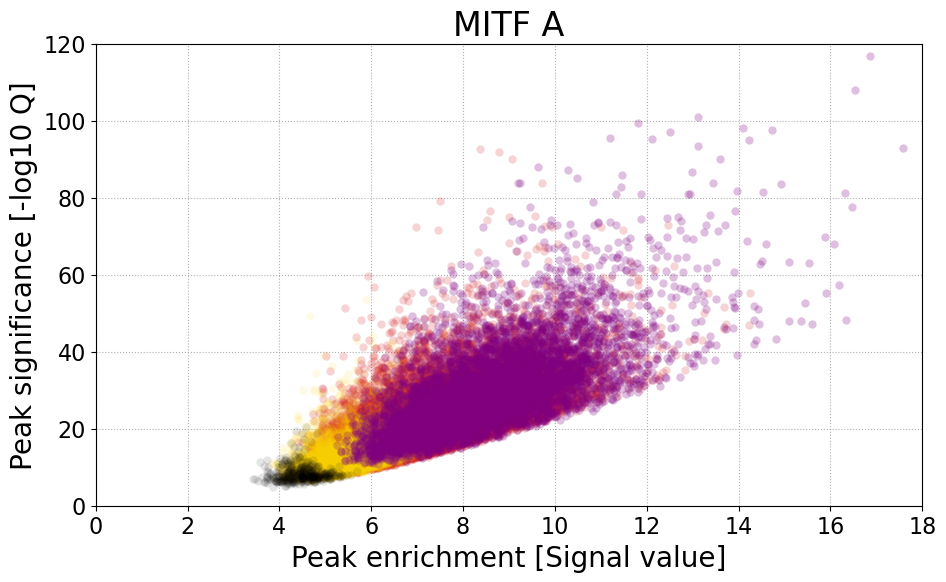

In [9]:
signal_threshold = 5         # encode signal
significance_threshold = 10  # encode significance threshold

# Boolean flags: does replicate i pass both thresholds?
pass_r1 = (df[3] >= signal_threshold) & (df[4] >= significance_threshold)
pass_r2 = (df[5] >= signal_threshold) & (df[6] >= significance_threshold)
pass_r3 = (df[7] >= signal_threshold) & (df[8] >= significance_threshold)

# Count how many replicates pass per row
pass_count = (pandas.concat([pass_r1, pass_r2, pass_r3], axis=1).sum(axis=1))

# arrange
df_black  = df.loc[pass_count == 0].copy()  # none pass
df_yellow = df.loc[pass_count == 1].copy()  # exactly one passes
df_orange = df.loc[pass_count == 2].copy()  # exactly two pass
df_red    = df.loc[pass_count == 3].copy()  # all three pass

print(df_red.shape)
print(df_orange.shape)
print(df_yellow.shape)
print(df_black.shape)

# plot
matplotlib.pyplot.plot(df_orange['signal'], df_orange['Q'], 'o', color='tab:red', alpha=0.2, mec='none')
matplotlib.pyplot.plot(df_yellow['signal'], df_yellow['Q'], 'o', color='gold', alpha=0.1, mec='none')
matplotlib.pyplot.plot(df_red['signal'], df_red['Q'], 'o', color='purple', alpha=0.25, mec='none')
matplotlib.pyplot.plot(df_black['signal'], df_black['Q'], 'o', color='black', alpha=0.1, mec='none')

matplotlib.pyplot.xlabel('Peak enrichment [Signal value]')
matplotlib.pyplot.ylabel('Peak significance [-log10 Q]')
matplotlib.pyplot.grid(ls=':')

matplotlib.pyplot.xlim(0, 18)
matplotlib.pyplot.ylim(0, 120)

matplotlib.pyplot.title('MITF A')

matplotlib.pyplot.show()

In [ ]:
# need to save in a table the purple peaks